# TS4 - Primeras nociones de estimación espectral

En esta tarea se estudia la estimación de amplitud y frecuencia de una senoidal inmersa en ruido blanco gaussiano.

La señal generada es:

\[
x[n] = a_0 \cdot \sin(\Omega_1 n) + n_a[n]
\]

donde la frecuencia de la senoidal presenta una desintonía aleatoria respecto de una frecuencia central.

In [1]:
# Módulos externos
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import windows
import pandas as pd
from IPython.display import display

## Parámetros de simulación

Se consideran 200 realizaciones de 1000 muestras cada una.

La amplitud se calibra como:

\[
a_0 = \sqrt{2}
\]

De esta forma, la potencia de la senoidal resulta:

\[
P_s = \frac{a_0^2}{2} = 1 W
\]

In [2]:
N = 1000
fs = 1000
ts = 1 / fs
R = 200

a0 = np.sqrt(2)
omega0 = N/4
df = fs/N

PS = (a0)**2/2

n = np.arange(N)
n = n.reshape(1, N)

t = np.arange(N)/fs
tt = (t).reshape(1, -1)

fr = np.random.uniform(-2, 2, R)

omega1 = omega0 + fr*df
omega1 = omega1.reshape(R,1)

arg = omega1*n

eps = 1e-12

## Generación de la señal con SNR = 10 dB

Primero se genera la señal para una relación señal a ruido de 10 dB.  
La potencia del ruido se calcula a partir de la potencia de la señal y de la SNR deseada.

In [3]:
SNR = 10

PR = PS / 10**(SNR/10)
desvio = np.sqrt(PR)

na = np.random.normal(0, desvio, size = (R, N))

señal = a0*np.sin(2*np.pi*arg*ts) + na
señal_t = np.transpose(señal)

## Visualización temporal de las realizaciones

Se grafican las 200 realizaciones de la señal en el dominio temporal.

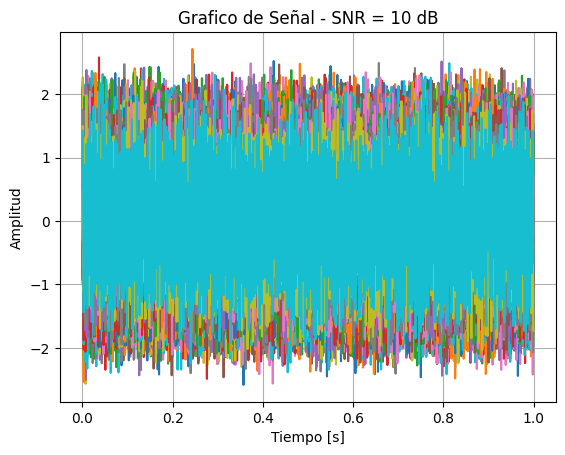

In [4]:
plt.figure()
plt.title('Grafico de Señal - SNR = 10 dB')
plt.plot(t, señal_t)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

## FFT de la señal sin ventaneo

Se calcula la FFT de cada realización y se representa su módulo en dB.  
Como se trata de una magnitud asociada a potencia, se utiliza:

\[
10 \log_{10}(\cdot)
\]

In [5]:
señal_X = np.fft.fft(señal, axis = 1) / N
psd_señal = np.abs(señal_X)
señal_x_db = 10*np.log10(2*(psd_señal)**2 + eps)

frec = np.arange(N) * fs / N
frec = frec.reshape(1000, 1)

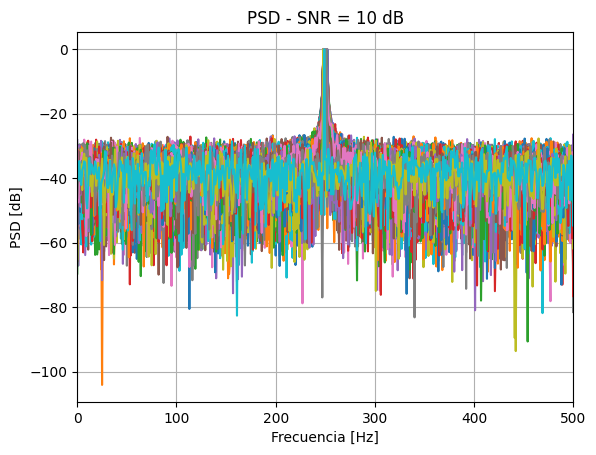

In [6]:
plt.figure()
plt.title('PSD - SNR = 10 dB')
plt.plot(frec, señal_x_db.T)
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()
plt.show()

## Aplicación de ventanas

Se analizan las siguientes ventanas:

- Rectangular
- Flat-top
- Blackman-Harris
- Hamming

Para la estimación de amplitud se corrige la ganancia coherente de cada ventana:

\[
G_c = \frac{1}{N}\sum_{n=0}^{N-1} w[n]
\]

Esta corrección es necesaria porque las ventanas modifican la amplitud observada en la FFT.

In [7]:
# Ganancia coherente de cada ventana
Gc_rec = np.mean(windows.boxcar(N))
Gc_flat = np.mean(windows.flattop(N))
Gc_blk = np.mean(windows.blackmanharris(N))
Gc_ham = np.mean(windows.hamming(N))

# Rectangular
w_rec = señal * windows.boxcar(N)

W_REC = np.fft.fft(w_rec, axis = 1) / N
W_REC_Mod = np.abs(W_REC)
W_REC_db = 10*np.log10(2*(W_REC_Mod)**2 + eps)
W_REC_db_t = np.transpose(W_REC_db)

# Flattop
w_flat = señal * windows.flattop(N)

W_FLAT = np.fft.fft(w_flat, axis = 1) / N
W_FLAT_Mod = np.abs(W_FLAT)
W_FLAT_db = 10*np.log10(2*(W_FLAT_Mod)**2 + eps)
W_FLAT_db_t = np.transpose(W_FLAT_db)

# Blackman-Harris
w_blk = señal * windows.blackmanharris(N)

W_BLK = np.fft.fft(w_blk, axis = 1) / N
W_BLK_Mod = np.abs(W_BLK)
W_BLK_db = 10*np.log10(2*(W_BLK_Mod)**2 + eps)
W_BLK_db_t = np.transpose(W_BLK_db)

# Hamming
w_ham = señal * windows.hamming(N)

W_HAM = np.fft.fft(w_ham, axis = 1) / N
W_HAM_Mod = np.abs(W_HAM)
W_HAM_db = 10*np.log10(2*(W_HAM_Mod)**2 + eps)
W_HAM_db_t = np.transpose(W_HAM_db)

## Comparación espectral de ventanas para SNR = 10 dB

Se grafica el espectro obtenido con cada ventana.  
Cada ventana modifica el compromiso entre ancho del lóbulo principal y nivel de lóbulos laterales.

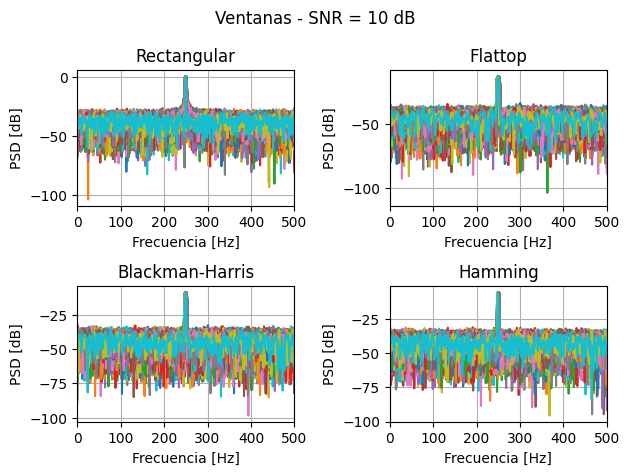

In [8]:
plt.figure()
plt.suptitle('Ventanas - SNR = 10 dB')

plt.subplot(2, 2, 1)
plt.title('Rectangular')
plt.plot(frec, W_REC_db_t)
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()

plt.subplot(2, 2, 2)
plt.title('Flattop')
plt.plot(frec, W_FLAT_db_t)
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()

plt.subplot(2, 2, 3)
plt.title('Blackman-Harris')
plt.plot(frec, W_BLK_db_t)
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()

plt.subplot(2, 2, 4)
plt.title('Hamming')
plt.plot(frec, W_HAM_db_t)
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()

plt.tight_layout()
plt.show()

## Estimador de amplitud para SNR = 10 dB

El estimador de amplitud se calcula en el bin correspondiente a la frecuencia central.  
Se multiplica por 2 porque se toma solamente el lado positivo del espectro, y se divide por la ganancia coherente de la ventana.

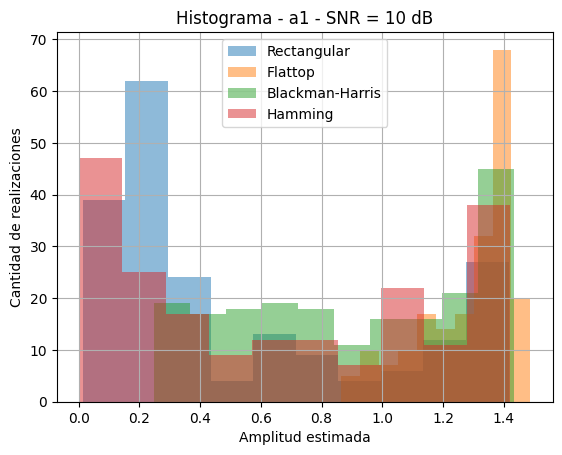

In [9]:
a1_rec_10 = np.abs(W_REC[:,N//4])*2/Gc_rec
a1_flat_10 = np.abs(W_FLAT[:,N//4])*2/Gc_flat
a1_blk_10 = np.abs(W_BLK[:,N//4])*2/Gc_blk
a1_ham_10 = np.abs(W_HAM[:,N//4])*2/Gc_ham

bins = 10

plt.figure()
plt.title('Histograma - a1 - SNR = 10 dB')
plt.hist(a1_rec_10, label = 'Rectangular', alpha = 0.5, bins = bins)
plt.hist(a1_flat_10, label = 'Flattop', alpha = 0.5, bins = bins)
plt.hist(a1_blk_10, label = 'Blackman-Harris', alpha = 0.5, bins = bins)
plt.hist(a1_ham_10, label = 'Hamming', alpha = 0.5, bins = bins)
plt.xlabel('Amplitud estimada')
plt.ylabel('Cantidad de realizaciones')
plt.grid()
plt.legend()
plt.show()

## Estimador de frecuencia para SNR = 10 dB

El estimador de frecuencia se obtiene buscando el máximo del módulo de la FFT en el rango de frecuencias positivas.  
Luego, el índice obtenido se convierte a Hz multiplicando por \(\Delta f\).

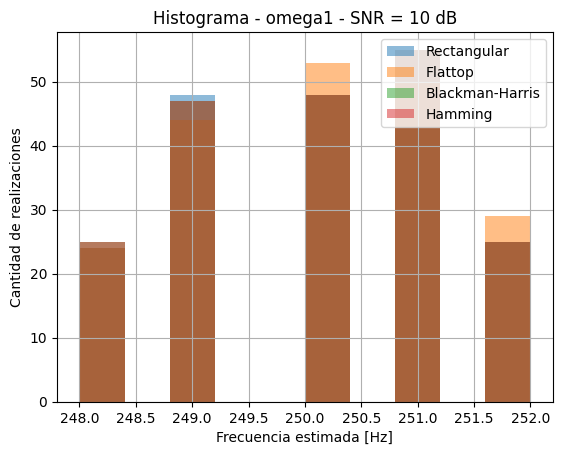

In [10]:
omegai_rec_10 = np.argmax(W_REC_Mod[:, :N//2], axis = 1) * df
omegai_flat_10 = np.argmax(W_FLAT_Mod[:, :N//2], axis = 1) * df
omegai_blk_10 = np.argmax(W_BLK_Mod[:, :N//2], axis = 1) * df
omegai_ham_10 = np.argmax(W_HAM_Mod[:, :N//2], axis = 1) * df

plt.figure()
plt.title('Histograma - omega1 - SNR = 10 dB')
plt.hist(omegai_rec_10, label = 'Rectangular', alpha = 0.5, bins = bins)
plt.hist(omegai_flat_10, label = 'Flattop', alpha = 0.5, bins = bins)
plt.hist(omegai_blk_10, label = 'Blackman-Harris', alpha = 0.5, bins = bins)
plt.hist(omegai_ham_10, label = 'Hamming', alpha = 0.5, bins = bins)
plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de realizaciones')
plt.grid()
plt.legend()
plt.show()

## Sesgo y varianza para SNR = 10 dB

Se calcula el sesgo y la varianza experimental de cada estimador.

El sesgo se define como:

\[
s_a = E\{\hat a\} - a_0
\]

y la varianza como:

\[
v_a = E\{(\hat a - E\{\hat a\})^2\}
\]

In [11]:
# Sesgo
# Amplitud
s_a1_rec_10 = np.mean(a1_rec_10) - a0
s_a1_flat_10 = np.mean(a1_flat_10) - a0
s_a1_blk_10 = np.mean(a1_blk_10) - a0
s_a1_ham_10 = np.mean(a1_ham_10) - a0

# Frecuencia
s_omegai_rec_10 = np.mean(omegai_rec_10) - np.mean(omega1)
s_omegai_flat_10 = np.mean(omegai_flat_10) - np.mean(omega1)
s_omegai_blk_10 = np.mean(omegai_blk_10) - np.mean(omega1)
s_omegai_ham_10 = np.mean(omegai_ham_10) - np.mean(omega1)

# Varianza
# Amplitud
v_a1_rec_10 = np.var(a1_rec_10)
v_a1_flat_10 = np.var(a1_flat_10)
v_a1_blk_10 = np.var(a1_blk_10)
v_a1_ham_10 = np.var(a1_ham_10)

# Frecuencia
v_omegai_rec_10 = np.var(omegai_rec_10)
v_omegai_flat_10 = np.var(omegai_flat_10)
v_omega1_blk_10 = np.var(omegai_blk_10)
v_omegai_ham_10 = np.var(omegai_ham_10)

# Tablas
tabla_amp_10 = pd.DataFrame({
    'Ventana': ['Rectangular', 'Flat-top', 'Blackman-Harris', 'Hamming'],
    's_a': [s_a1_rec_10, s_a1_flat_10, s_a1_blk_10, s_a1_ham_10],
    'v_a': [v_a1_rec_10, v_a1_flat_10, v_a1_blk_10, v_a1_ham_10]
})

tabla_frec_10 = pd.DataFrame({
    'Ventana': ['Rectangular', 'Flat-top', 'Blackman-Harris', 'Hamming'],
    's_f': [s_omegai_rec_10, s_omegai_flat_10, s_omegai_blk_10, s_omegai_ham_10],
    'v_f': [v_omegai_rec_10, v_omegai_flat_10, v_omega1_blk_10, v_omegai_ham_10]
})

print('Estimación de Amplitud - SNR = 10 dB')
display(tabla_amp_10)

print('Estimación de Frecuencia - SNR = 10 dB')
display(tabla_frec_10)

Estimación de Amplitud - SNR = 10 dB


,Ventana,s_a,v_a
0,Rectangular,-0.891278,0.210157
1,Flat-top,-0.130512,0.023421
2,Blackman-Harris,-0.501408,0.141910
3,Hamming,-0.766111,0.254883


Estimación de Frecuencia - SNR = 10 dB


,Ventana,s_f,v_f
0,Rectangular,-0.003948,1.492975
1,Flat-top,0.031052,1.523600
2,Blackman-Harris,-0.008948,1.508400
3,Hamming,-0.008948,1.508400


# Experimento con SNR = 3 dB

Se repite el procedimiento anterior, pero ahora con una SNR menor.  
Al aumentar el ruido, se espera que aumente la dispersión de los estimadores.

In [12]:
SNR = 3

PR = PS / 10**(SNR/10)
desvio = np.sqrt(PR)

na = np.random.normal(0, desvio, size = (R, N))

señal = a0*np.sin(2*np.pi*arg*ts) + na

## Aplicación de ventanas para SNR = 3 dB

In [13]:
# Rectangular
w_rec = señal * windows.boxcar(N)

W_REC = np.fft.fft(w_rec, axis = 1) / N
W_REC_Mod = np.abs(W_REC)
W_REC_db = 10*np.log10(2*(W_REC_Mod)**2 + eps)
W_REC_db_t = np.transpose(W_REC_db)

# Flattop
w_flat = señal * windows.flattop(N)

W_FLAT = np.fft.fft(w_flat, axis = 1) / N
W_FLAT_Mod = np.abs(W_FLAT)
W_FLAT_db = 10*np.log10(2*(W_FLAT_Mod)**2 + eps)
W_FLAT_db_t = np.transpose(W_FLAT_db)

# Blackman-Harris
w_blk = señal * windows.blackmanharris(N)

W_BLK = np.fft.fft(w_blk, axis = 1) / N
W_BLK_Mod = np.abs(W_BLK)
W_BLK_db = 10*np.log10(2*(W_BLK_Mod)**2 + eps)
W_BLK_db_t = np.transpose(W_BLK_db)

# Hamming
w_ham = señal * windows.hamming(N)

W_HAM = np.fft.fft(w_ham, axis = 1) / N
W_HAM_Mod = np.abs(W_HAM)
W_HAM_db = 10*np.log10(2*(W_HAM_Mod)**2 + eps)
W_HAM_db_t = np.transpose(W_HAM_db)

## Comparación espectral de ventanas para SNR = 3 dB

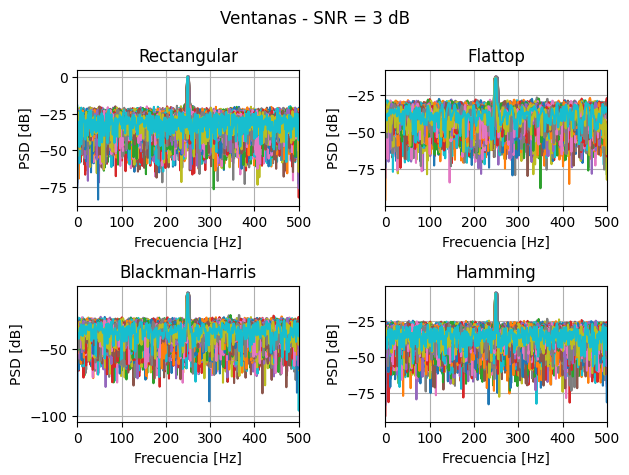

In [14]:
plt.figure()
plt.suptitle('Ventanas - SNR = 3 dB')

plt.subplot(2, 2, 1)
plt.title('Rectangular')
plt.plot(frec, W_REC_db_t)
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()

plt.subplot(2, 2, 2)
plt.title('Flattop')
plt.plot(frec, W_FLAT_db_t)
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()

plt.subplot(2, 2, 3)
plt.title('Blackman-Harris')
plt.plot(frec, W_BLK_db_t)
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()

plt.subplot(2, 2, 4)
plt.title('Hamming')
plt.plot(frec, W_HAM_db_t)
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()

plt.tight_layout()
plt.show()

## Estimadores de amplitud y frecuencia para SNR = 3 dB

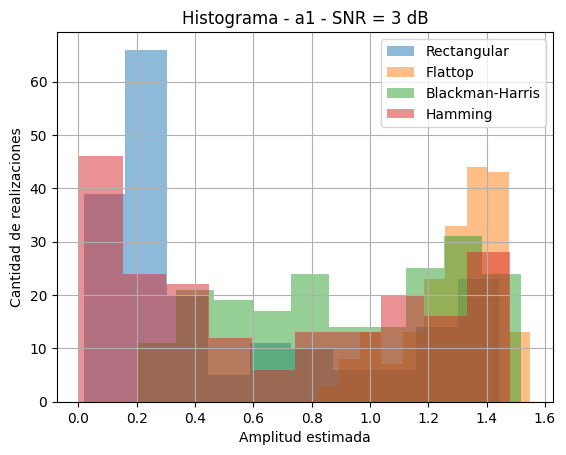

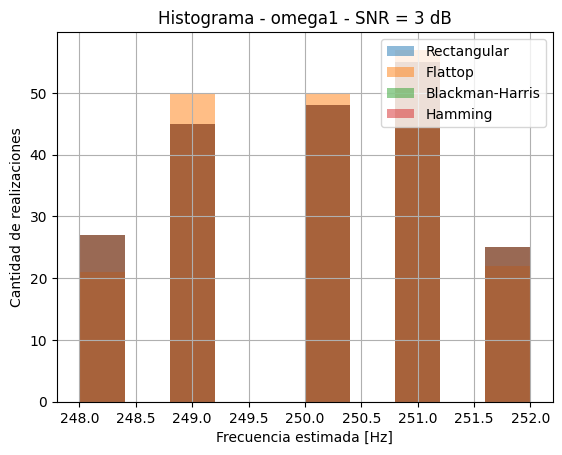

In [15]:
# Estimador de amplitud
a1_rec_3 = np.abs(W_REC[:,N//4])*2/Gc_rec
a1_flat_3 = np.abs(W_FLAT[:,N//4])*2/Gc_flat
a1_blk_3 = np.abs(W_BLK[:,N//4])*2/Gc_blk
a1_ham_3 = np.abs(W_HAM[:,N//4])*2/Gc_ham

plt.figure()
plt.title('Histograma - a1 - SNR = 3 dB')
plt.hist(a1_rec_3, label = 'Rectangular', alpha = 0.5, bins = bins)
plt.hist(a1_flat_3, label = 'Flattop', alpha = 0.5, bins = bins)
plt.hist(a1_blk_3, label = 'Blackman-Harris', alpha = 0.5, bins = bins)
plt.hist(a1_ham_3, label = 'Hamming', alpha = 0.5, bins = bins)
plt.xlabel('Amplitud estimada')
plt.ylabel('Cantidad de realizaciones')
plt.grid()
plt.legend()
plt.show()

# Estimador de frecuencia
omegai_rec_3 = np.argmax(W_REC_Mod[:, :N//2], axis = 1) * df
omegai_flat_3 = np.argmax(W_FLAT_Mod[:, :N//2], axis = 1) * df
omegai_blk_3 = np.argmax(W_BLK_Mod[:, :N//2], axis = 1) * df
omegai_ham_3 = np.argmax(W_HAM_Mod[:, :N//2], axis = 1) * df

plt.figure()
plt.title('Histograma - omega1 - SNR = 3 dB')
plt.hist(omegai_rec_3, label = 'Rectangular', alpha = 0.5, bins = bins)
plt.hist(omegai_flat_3, label = 'Flattop', alpha = 0.5, bins = bins)
plt.hist(omegai_blk_3, label = 'Blackman-Harris', alpha = 0.5, bins = bins)
plt.hist(omegai_ham_3, label = 'Hamming', alpha = 0.5, bins = bins)
plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de realizaciones')
plt.grid()
plt.legend()
plt.show()

## Sesgo y varianza para SNR = 3 dB

In [16]:
# Sesgo
# Amplitud
s_a1_rec_3 = np.mean(a1_rec_3) - a0
s_a1_flat_3 = np.mean(a1_flat_3) - a0
s_a1_blk_3 = np.mean(a1_blk_3) - a0
s_a1_ham_3 = np.mean(a1_ham_3) - a0

# Frecuencia
s_omegai_rec_3 = np.mean(omegai_rec_3) - np.mean(omega1)
s_omegai_flat_3 = np.mean(omegai_flat_3) - np.mean(omega1)
s_omegai_blk_3 = np.mean(omegai_blk_3) - np.mean(omega1)
s_omegai_ham_3 = np.mean(omegai_ham_3) - np.mean(omega1)

# Varianza
# Amplitud
v_a1_rec_3 = np.var(a1_rec_3)
v_a1_flat_3 = np.var(a1_flat_3)
v_a1_blk_3 = np.var(a1_blk_3)
v_a1_ham_3 = np.var(a1_ham_3)

# Frecuencia
v_omegai_rec_3 = np.var(omegai_rec_3)
v_omegai_flat_3 = np.var(omegai_flat_3)
v_omega1_blk_3 = np.var(omegai_blk_3)
v_omegai_ham_3 = np.var(omegai_ham_3)

# Tablas
tabla_amp_3 = pd.DataFrame({
    'Ventana': ['Rectangular', 'Flat-top', 'Blackman-Harris', 'Hamming'],
    's_a': [s_a1_rec_3, s_a1_flat_3, s_a1_blk_3, s_a1_ham_3],
    'v_a': [v_a1_rec_3, v_a1_flat_3, v_a1_blk_3, v_a1_ham_3]
})

tabla_frec_3 = pd.DataFrame({
    'Ventana': ['Rectangular', 'Flat-top', 'Blackman-Harris', 'Hamming'],
    's_f': [s_omegai_rec_3, s_omegai_flat_3, s_omegai_blk_3, s_omegai_ham_3],
    'v_f': [v_omegai_rec_3, v_omegai_flat_3, v_omega1_blk_3, v_omegai_ham_3]
})

print('Estimación de Amplitud - SNR = 3 dB')
display(tabla_amp_3)

print('Estimación de Frecuencia - SNR = 3 dB')
display(tabla_frec_3)

Estimación de Amplitud - SNR = 3 dB


,Ventana,s_a,v_a
0,Rectangular,-0.888664,0.208851
1,Flat-top,-0.123572,0.026243
2,Blackman-Harris,-0.495031,0.142347
3,Hamming,-0.757340,0.249514


Estimación de Frecuencia - SNR = 3 dB


,Ventana,s_f,v_f
0,Rectangular,-0.018948,1.539100
1,Flat-top,-0.003948,1.392975
2,Blackman-Harris,-0.018948,1.539100
3,Hamming,-0.018948,1.539100


## Bonus: efecto del zero-padding

El zero-padding consiste en agregar ceros a la señal antes de calcular la FFT.  
Esto no agrega información nueva, pero permite observar el espectro sobre una grilla de frecuencia más fina.

Por lo tanto, puede mejorar la ubicación del máximo espectral cuando el estimador de frecuencia se basa en buscar el máximo de la FFT.

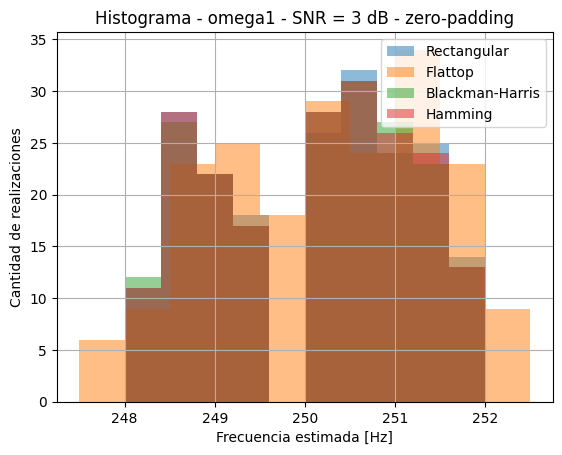

In [17]:
N_zp = 2000
df_zp = fs / N_zp

zp_W_REC = np.fft.fft(w_rec, n = N_zp, axis = 1)
zp_W_REC_Mod = np.abs(zp_W_REC)

zp_W_FLAT = np.fft.fft(w_flat, n = N_zp, axis = 1)
zp_W_FLAT_Mod = np.abs(zp_W_FLAT)

zp_W_BLK = np.fft.fft(w_blk, n = N_zp, axis = 1)
zp_W_BLK_Mod = np.abs(zp_W_BLK)

zp_W_HAM = np.fft.fft(w_ham, n = N_zp, axis = 1)
zp_W_HAM_Mod = np.abs(zp_W_HAM)

zp_omegai_rec_3 = np.argmax(zp_W_REC_Mod[:, :N_zp//2], axis = 1) * df_zp
zp_omegai_flat_3 = np.argmax(zp_W_FLAT_Mod[:, :N_zp//2], axis = 1) * df_zp
zp_omegai_blk_3 = np.argmax(zp_W_BLK_Mod[:, :N_zp//2], axis = 1) * df_zp
zp_omegai_ham_3 = np.argmax(zp_W_HAM_Mod[:, :N_zp//2], axis = 1) * df_zp

plt.figure()
plt.title('Histograma - omega1 - SNR = 3 dB - zero-padding')
plt.hist(zp_omegai_rec_3, label = 'Rectangular', alpha = 0.5, bins = bins)
plt.hist(zp_omegai_flat_3, label = 'Flattop', alpha = 0.5, bins = bins)
plt.hist(zp_omegai_blk_3, label = 'Blackman-Harris', alpha = 0.5, bins = bins)
plt.hist(zp_omegai_ham_3, label = 'Hamming', alpha = 0.5, bins = bins)
plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de realizaciones')
plt.grid()
plt.legend()
plt.show()

## Tabla para el estimador de frecuencia con zero-padding

Se calcula nuevamente el sesgo y la varianza del estimador de frecuencia, pero usando la FFT con zero-padding.

In [18]:
s_zp_omegai_rec_3 = np.mean(zp_omegai_rec_3) - np.mean(omega1)
s_zp_omegai_flat_3 = np.mean(zp_omegai_flat_3) - np.mean(omega1)
s_zp_omegai_blk_3 = np.mean(zp_omegai_blk_3) - np.mean(omega1)
s_zp_omegai_ham_3 = np.mean(zp_omegai_ham_3) - np.mean(omega1)

v_zp_omegai_rec_3 = np.var(zp_omegai_rec_3)
v_zp_omegai_flat_3 = np.var(zp_omegai_flat_3)
v_zp_omegai_blk_3 = np.var(zp_omegai_blk_3)
v_zp_omegai_ham_3 = np.var(zp_omegai_ham_3)

tabla_frec_zp_3 = pd.DataFrame({
    'Ventana': ['Rectangular', 'Flat-top', 'Blackman-Harris', 'Hamming'],
    's_f': [s_zp_omegai_rec_3, s_zp_omegai_flat_3, s_zp_omegai_blk_3, s_zp_omegai_ham_3],
    'v_f': [v_zp_omegai_rec_3, v_zp_omegai_flat_3, v_zp_omegai_blk_3, v_zp_omegai_ham_3]
})

print('Estimación de Frecuencia con zero-padding - SNR = 3 dB')
display(tabla_frec_zp_3)

Estimación de Frecuencia con zero-padding - SNR = 3 dB


,Ventana,s_f,v_f
0,Rectangular,0.003552,1.385994
1,Flat-top,-0.058948,1.434900
2,Blackman-Harris,-0.008948,1.365900
3,Hamming,-0.003948,1.362975


## Conclusiones

Se observa que las ventanas afectan de manera distinta a los estimadores de amplitud y frecuencia.

Para la estimación de amplitud, es importante corregir la ganancia coherente de cada ventana, ya que al multiplicar la señal por una ventana distinta de la rectangular se modifica la amplitud observada en la FFT.

La ventana flat-top suele ser favorable para estimar amplitud porque está diseñada para reducir errores cuando la frecuencia de la señal no coincide exactamente con un bin de la DFT.

Para la estimación de frecuencia, el estimador basado en el máximo de la FFT depende de la resolución frecuencial. Al aplicar zero-padding, la grilla de frecuencia se vuelve más fina y el máximo puede ubicarse con mayor precisión.

Al comparar SNR = 10 dB con SNR = 3 dB, se observa que al aumentar el ruido aumenta la dispersión de los estimadores, lo cual se refleja principalmente en una mayor varianza.